# Intersecting Spheres

**AUTHOR**  
Rodrigo Kang

## Computational Setup

This section imports the libraries required throughout the notebook and creates the directory structure used to store the numerical results. All figures are saved in `outputs-intersecting-spheres/figures`, while tables are written to `outputs-intersecting-spheres/tables`. Creating these directories at the beginning ensures that subsequent sections can save outputs without additional setup.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.interpolate import RegularGridInterpolator
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


# Output directories
output_dir = Path("outputs-intersecting-spheres")

figures_dir = (
    output_dir
    / "figures"
)

tables_dir = (
    output_dir
    / "tables"
)

figures_dir.mkdir(
    parents=True,
    exist_ok=True,
)

tables_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# Plot configuration
plt.rcParams.update(
    {
        "figure.figsize": (7, 6),
        "figure.dpi": 300,
        "font.size": 11,
        "axes.grid": False,
    }
)

## Numerical Domain

The inversion maps the interior intersection of the two spheres onto the unbounded region

$$
x' \ge 1,
\qquad
y' \ge 1,
\qquad
-\infty < z' < \infty.
$$

Because the transformed boundary condition on the plane $y'=1$ depends explicitly on $z'$, the transformed potential is not two-dimensional. The numerical problem must therefore be solved on a three-dimensional Cartesian domain.

For the finite difference approximation, the unbounded transformed region is truncated to

$$
1 \le x' \le L_x,
\qquad
1 \le y' \le L_y,
\qquad
-L_z \le z' \le L_z.
$$

A uniform Cartesian grid is introduced in each coordinate direction. The truncation limits and grid resolution determine the balance between computational cost and the approximation of the unbounded domain.

In [2]:
# Computational domain
x_min = 1.0
x_max = 8.0

y_min = 1.0
y_max = 8.0

z_min = -6.0
z_max = 6.0


# Grid resolution
num_points_x = 61
num_points_y = 61
num_points_z = 81


# Uniform Cartesian grid
x_coordinates = np.linspace(
    x_min,
    x_max,
    num_points_x,
)

y_coordinates = np.linspace(
    y_min,
    y_max,
    num_points_y,
)

z_coordinates = np.linspace(
    z_min,
    z_max,
    num_points_z,
)


# Grid spacing
grid_spacing_x = (
    x_coordinates[1]
    - x_coordinates[0]
)

grid_spacing_y = (
    y_coordinates[1]
    - y_coordinates[0]
)

grid_spacing_z = (
    z_coordinates[1]
    - z_coordinates[0]
)

x_grid, y_grid, z_grid = np.meshgrid(
    x_coordinates,
    y_coordinates,
    z_coordinates,
    indexing="ij",
)

## Boundary Conditions

The transformed problem is subject to prescribed Dirichlet conditions on the two conducting boundaries. The plane $y'=1$, corresponding to the sphere maintained at $1\,\mathrm{V}$, is assigned a potential of unity, while the plane $x'=1$, corresponding to the grounded sphere, is assigned a potential of zero:

$$
\tilde{\phi}(x',1)=1,
\qquad
\tilde{\phi}(1,y')=0.
$$

The transformed region is unbounded in both coordinate directions. Since the numerical domain is truncated at $x'=L$ and $y'=L$, artificial boundary conditions must also be imposed along the outer edges. A homogeneous Neumann condition is used to approximate the vanishing normal derivative expected sufficiently far from the conducting boundaries:

$$
\frac{\partial \tilde{\phi}}{\partial x'}(L,y')=0,
\qquad
\frac{\partial \tilde{\phi}}{\partial y'}(x',L)=0.
$$

At the corner $(1,1)$, where the two conducting boundaries meet and the prescribed values are discontinuous, the potential is assigned the average value $1/2$. This local convention regularises the discrete problem without affecting the solution away from the corner as the grid is refined.

In [3]:
# Boundary potentials
upper_boundary_potential = 1.0
lower_boundary_potential = 0.0

corner_potential = (
    upper_boundary_potential
    + lower_boundary_potential
) / 2.0


# Initial potential field
transformed_potential = np.zeros(
    (
        num_points_y,
        num_points_x,
    ),
    dtype=float,
)


# Dirichlet boundary conditions
transformed_potential[0, :] = (
    upper_boundary_potential
)

transformed_potential[:, 0] = (
    lower_boundary_potential
)

transformed_potential[0, 0] = (
    corner_potential
)

## Finite Difference Discretisation

Laplace's equation in the transformed Cartesian coordinates is

$$
\frac{\partial^2 \tilde{\phi}}{\partial x'^2}
+
\frac{\partial^2 \tilde{\phi}}{\partial y'^2}
=
0.
$$

At an interior grid point $(x'_i,y'_j)$, the second derivatives are approximated using centred finite differences:

$$
\frac{\partial^2 \tilde{\phi}}{\partial x'^2}
\approx
\frac{
\tilde{\phi}_{j,i+1}
-
2\tilde{\phi}_{j,i}
+
\tilde{\phi}_{j,i-1}
}{
\Delta x'^2
},
$$

and

$$
\frac{\partial^2 \tilde{\phi}}{\partial y'^2}
\approx
\frac{
\tilde{\phi}_{j+1,i}
-
2\tilde{\phi}_{j,i}
+
\tilde{\phi}_{j-1,i}
}{
\Delta y'^2
}.
$$

Substituting these expressions into Laplace's equation gives the discrete relation

$$
\frac{
\tilde{\phi}_{j,i+1}
-
2\tilde{\phi}_{j,i}
+
\tilde{\phi}_{j,i-1}
}{
\Delta x'^2
}
+
\frac{
\tilde{\phi}_{j+1,i}
-
2\tilde{\phi}_{j,i}
+
\tilde{\phi}_{j-1,i}
}{
\Delta y'^2
}
=
0.
$$

The prescribed potentials on $x'=1$ and $y'=1$ are incorporated as Dirichlet equations. Along the artificial outer boundaries, the homogeneous Neumann conditions are approximated using one-sided differences:

$$
\tilde{\phi}_{j,N_x-1}
-
\tilde{\phi}_{j,N_x-2}
=
0,
$$

and

$$
\tilde{\phi}_{N_y-1,i}
-
\tilde{\phi}_{N_y-2,i}
=
0.
$$

At the outer corner, the potential is constrained to equal the average of its two adjacent grid values. The resulting equations form a sparse linear system

$$
\mathbf{A}\mathbf{u}
=
\mathbf{b},
$$

where $\mathbf{u}$ contains the transformed potential at every grid point.

In [4]:
def build_laplace_system(
    num_points_x,
    num_points_y,
    grid_spacing_x,
    grid_spacing_y,
    upper_boundary_potential,
    lower_boundary_potential,
    corner_potential,
):
    """
    Build the sparse finite difference system for the transformed potential

    Inputs:
    -------
    num_points_x : int
        Number of grid points in the horizontal coordinate

    num_points_y : int
        Number of grid points in the vertical coordinate

    grid_spacing_x : float
        Uniform grid spacing in the horizontal coordinate

    grid_spacing_y : float
        Uniform grid spacing in the vertical coordinate

    upper_boundary_potential : float
        Prescribed potential along the boundary y'=1

    lower_boundary_potential : float
        Prescribed potential along the boundary x'=1

    corner_potential : float
        Potential assigned to the corner where the Dirichlet boundaries meet

    Outputs:
    --------
    system_matrix : scipy.sparse.csr_matrix
        Sparse coefficient matrix of the finite difference system

    right_hand_side : numpy.ndarray
        Right-hand-side vector of the finite difference system

    Author:
    -------
    Rodrigo Kang

    """
    num_unknowns = (
        num_points_x
        * num_points_y
    )

    system_matrix = lil_matrix(
        (
            num_unknowns,
            num_unknowns,
        ),
        dtype=float,
    )

    right_hand_side = np.zeros(
        num_unknowns,
        dtype=float,
    )

    inverse_spacing_x_squared = (
        1.0
        / grid_spacing_x**2
    )

    inverse_spacing_y_squared = (
        1.0
        / grid_spacing_y**2
    )

    def grid_index(
        x_index,
        y_index,
    ):
        return (
            y_index
            * num_points_x
            + x_index
        )

    for y_index in range(num_points_y):
        for x_index in range(num_points_x):
            row_index = grid_index(
                x_index=x_index,
                y_index=y_index,
            )

            # Corner shared by the two conducting boundaries
            if (
                x_index == 0
                and y_index == 0
            ):
                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                right_hand_side[
                    row_index
                ] = corner_potential

            # Grounded boundary x'=1
            elif x_index == 0:
                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                right_hand_side[
                    row_index
                ] = lower_boundary_potential

            # Unit-potential boundary y'=1
            elif y_index == 0:
                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                right_hand_side[
                    row_index
                ] = upper_boundary_potential

            # Outer corner with two homogeneous Neumann conditions
            elif (
                x_index == num_points_x - 1
                and y_index == num_points_y - 1
            ):
                left_index = grid_index(
                    x_index=x_index - 1,
                    y_index=y_index,
                )

                lower_index = grid_index(
                    x_index=x_index,
                    y_index=y_index - 1,
                )

                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                system_matrix[
                    row_index,
                    left_index,
                ] = -0.5

                system_matrix[
                    row_index,
                    lower_index,
                ] = -0.5

            # Homogeneous Neumann condition at x'=L
            elif x_index == num_points_x - 1:
                left_index = grid_index(
                    x_index=x_index - 1,
                    y_index=y_index,
                )

                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                system_matrix[
                    row_index,
                    left_index,
                ] = -1.0

            # Homogeneous Neumann condition at y'=L
            elif y_index == num_points_y - 1:
                lower_index = grid_index(
                    x_index=x_index,
                    y_index=y_index - 1,
                )

                system_matrix[
                    row_index,
                    row_index,
                ] = 1.0

                system_matrix[
                    row_index,
                    lower_index,
                ] = -1.0

            # Interior Laplace equation
            else:
                left_index = grid_index(
                    x_index=x_index - 1,
                    y_index=y_index,
                )

                right_index = grid_index(
                    x_index=x_index + 1,
                    y_index=y_index,
                )

                lower_index = grid_index(
                    x_index=x_index,
                    y_index=y_index - 1,
                )

                upper_index = grid_index(
                    x_index=x_index,
                    y_index=y_index + 1,
                )

                system_matrix[
                    row_index,
                    row_index,
                ] = (
                    -2.0
                    * inverse_spacing_x_squared
                    - 2.0
                    * inverse_spacing_y_squared
                )

                system_matrix[
                    row_index,
                    left_index,
                ] = inverse_spacing_x_squared

                system_matrix[
                    row_index,
                    right_index,
                ] = inverse_spacing_x_squared

                system_matrix[
                    row_index,
                    lower_index,
                ] = inverse_spacing_y_squared

                system_matrix[
                    row_index,
                    upper_index,
                ] = inverse_spacing_y_squared

    return (
        system_matrix.tocsr(),
        right_hand_side,
    )

In [5]:
system_matrix, right_hand_side = (
    build_laplace_system(
        num_points_x=num_points_x,
        num_points_y=num_points_y,
        grid_spacing_x=grid_spacing_x,
        grid_spacing_y=grid_spacing_y,
        upper_boundary_potential=upper_boundary_potential,
        lower_boundary_potential=lower_boundary_potential,
        corner_potential=corner_potential,
    )
)

## Numerical Solution

The sparse linear system obtained from the finite difference discretisation is solved using a direct sparse solver. The resulting one-dimensional solution vector is then reshaped into the Cartesian grid so that the transformed potential can be analysed and visualised over the computational domain.

Because the linear indexing used during matrix assembly follows the ordering

$$
k=jN_x+i,
$$

the solution vector is reshaped into an array with dimensions $(N_y,N_x)$. The first index therefore corresponds to the $y'$ coordinate, while the second corresponds to the $x'$ coordinate.

In [6]:
def solve_laplace_system(
    system_matrix,
    right_hand_side,
    num_points_x,
    num_points_y,
):
    """
    Solve the sparse finite difference system for the transformed potential

    Inputs:
    -------
    system_matrix : scipy.sparse.csr_matrix
        Sparse coefficient matrix of the finite difference system

    right_hand_side : numpy.ndarray
        Right-hand-side vector of the finite difference system

    num_points_x : int
        Number of grid points in the horizontal coordinate

    num_points_y : int
        Number of grid points in the vertical coordinate

    Outputs:
    --------
    transformed_potential : numpy.ndarray
        Two-dimensional transformed potential field

    Author:
    -------
    Rodrigo Kang

    """
    solution_vector = spsolve(
        system_matrix,
        right_hand_side,
    )

    transformed_potential = solution_vector.reshape(
        (
            num_points_y,
            num_points_x,
        )
    )

    return transformed_potential

In [7]:
transformed_potential = solve_laplace_system(
    system_matrix=system_matrix,
    right_hand_side=right_hand_side,
    num_points_x=num_points_x,
    num_points_y=num_points_y,
)

The computed potential should remain between the prescribed boundary values throughout the domain, in accordance with the maximum principle for harmonic functions. The following values provide an initial numerical check of the solution range.

In [8]:
minimum_transformed_potential = np.min(
    transformed_potential
)

maximum_transformed_potential = np.max(
    transformed_potential
)

print(
    "Minimum transformed potential: "
    f"{minimum_transformed_potential:.6f}"
)

print(
    "Maximum transformed potential: "
    f"{maximum_transformed_potential:.6f}"
)

Minimum transformed potential: 0.000000
Maximum transformed potential: 1.000000


## Transformed Potential

The numerical solution is first visualised in the transformed Cartesian domain. A filled contour plot shows how the potential varies between the two conducting boundaries and approaches a nearly constant distribution toward the artificial outer boundaries.

The contour lines represent equipotential curves of the transformed problem. Their concentration near the corner $(1,1)$ reflects the rapid variation produced by the discontinuity between the prescribed boundary values.

In [9]:
def plot_transformed_potential(
    x_coordinates,
    y_coordinates,
    transformed_potential,
    figures_dir,
):
    """
    Plot and save the potential in the transformed domain

    Inputs:
    -------
    x_coordinates : numpy.ndarray
        One-dimensional horizontal coordinates

    y_coordinates : numpy.ndarray
        One-dimensional vertical coordinates

    transformed_potential : numpy.ndarray
        Two-dimensional transformed potential field

    figures_dir : pathlib.Path
        Directory used to save the generated figure

    Outputs:
    --------
    figure_path : pathlib.Path
        Path of the saved transformed-potential figure

    Author:
    -------
    Rodrigo Kang

    """
    figure, axis = plt.subplots()

    filled_contours = axis.contourf(
        x_coordinates,
        y_coordinates,
        transformed_potential,
        levels=40,
        cmap="viridis",
    )

    contour_lines = axis.contour(
        x_coordinates,
        y_coordinates,
        transformed_potential,
        levels=np.linspace(
            0.0,
            1.0,
            11,
        ),
        colors="black",
        linewidths=0.5,
        alpha=0.6,
    )

    axis.clabel(
        contour_lines,
        inline=True,
        fontsize=8,
        fmt="%.1f",
    )

    colorbar = figure.colorbar(
        filled_contours,
        ax=axis,
    )

    colorbar.set_label(
        r"Transformed potential $\tilde{\phi}$"
    )

    axis.set_xlabel(
        r"$x'$"
    )

    axis.set_ylabel(
        r"$y'$"
    )

    axis.set_title(
        "Potential in the Transformed Domain"
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    figure.tight_layout()

    figure_path = (
        figures_dir
        / "transformed-potential.png"
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close(figure)

    return figure_path

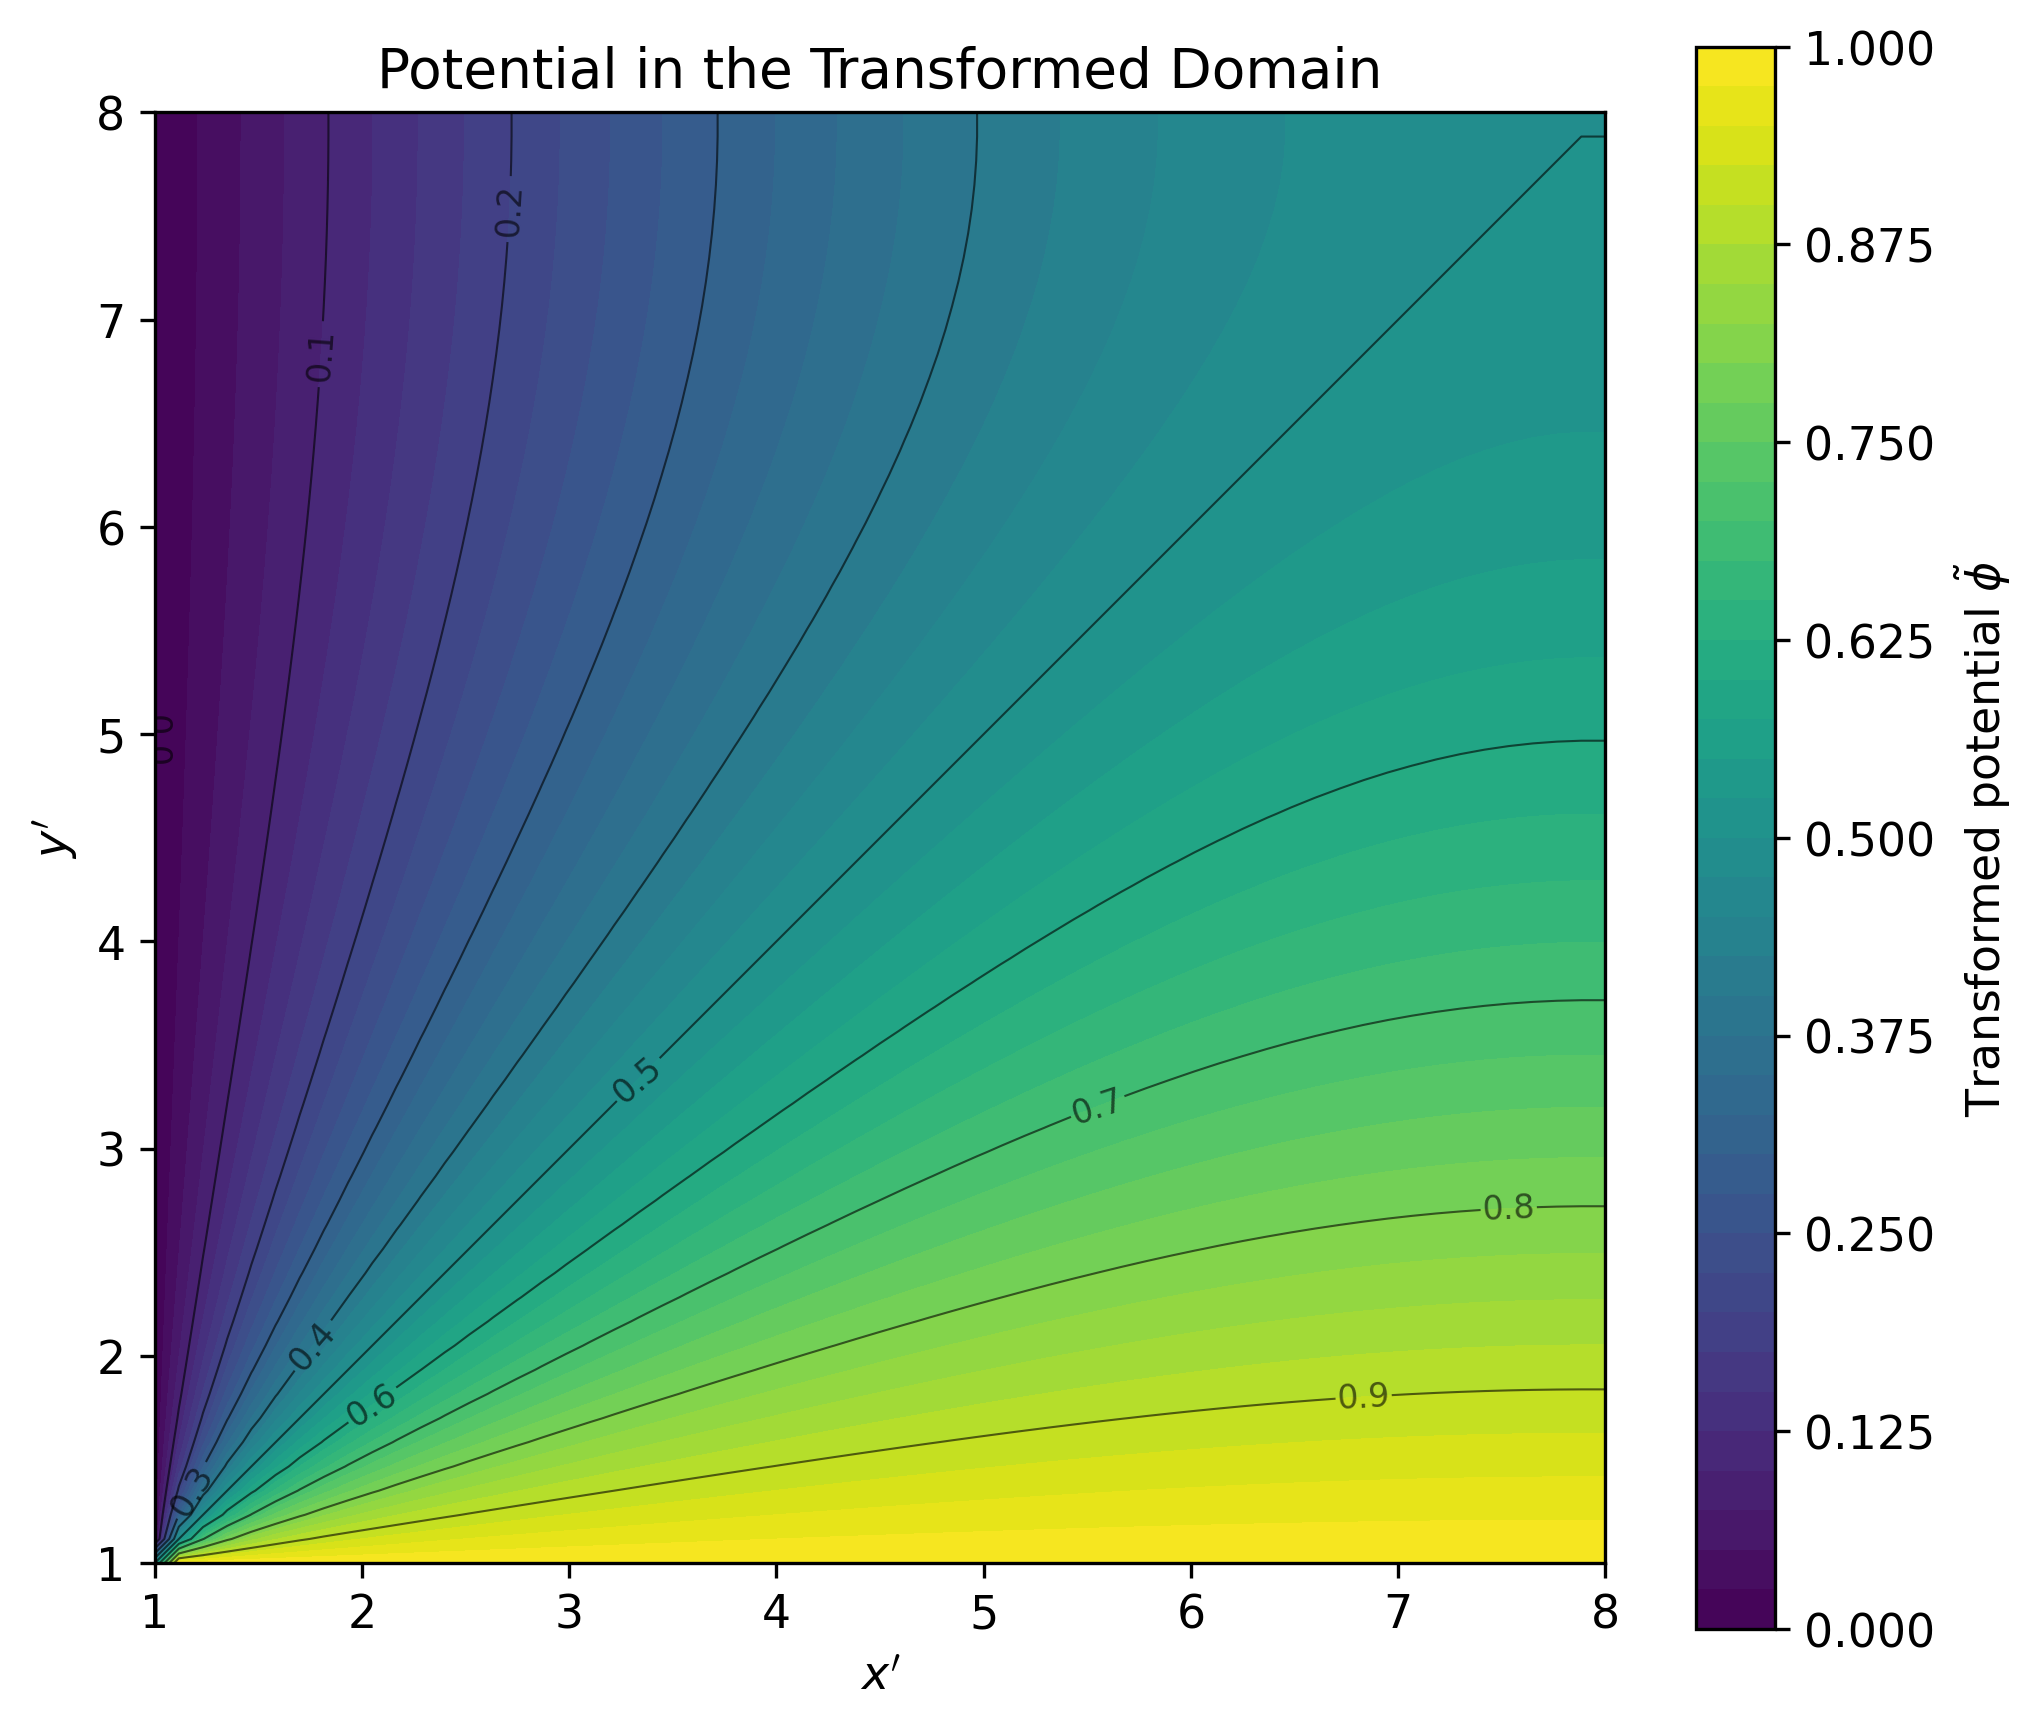

In [10]:
transformed_potential_figure_path = (
    plot_transformed_potential(
        x_coordinates=x_coordinates,
        y_coordinates=y_coordinates,
        transformed_potential=transformed_potential,
        figures_dir=figures_dir,
    )
)

## Inverse Transformation

The numerical solution obtained in the transformed domain must be mapped back to the original lens-shaped geometry. Under inversion, a point $(x,y)$ in the original coordinate plane is mapped to

$$
x'
=
\frac{x}{x^2+y^2},
\qquad
y'
=
\frac{y}{x^2+y^2}.
$$

The transformed potential is known only at the nodes of the Cartesian finite difference grid. A regular-grid interpolator is therefore constructed to evaluate the numerical solution at the inverted coordinates.

The reconstructed potential in the original domain is obtained by evaluating the transformed auxiliary solution at the corresponding inverted points:

$$
\phi(x,y)
=
\tilde{\phi}
\left(
\frac{x}{x^2+y^2},
\frac{y}{x^2+y^2}
\right).
$$

Only points lying inside both spheres are retained. Points whose inverted coordinates fall outside the truncated transformed domain are excluded from the reconstructed field.

In [11]:
def create_potential_interpolator(
    x_coordinates,
    y_coordinates,
    transformed_potential,
):
    """
    Create an interpolator for the transformed potential

    Inputs:
    -------
    x_coordinates : numpy.ndarray
        One-dimensional horizontal coordinates of the transformed grid

    y_coordinates : numpy.ndarray
        One-dimensional vertical coordinates of the transformed grid

    transformed_potential : numpy.ndarray
        Two-dimensional transformed potential field

    Outputs:
    --------
    potential_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the transformed potential

    Author:
    -------
    Rodrigo Kang

    """
    potential_interpolator = RegularGridInterpolator(
        (
            y_coordinates,
            x_coordinates,
        ),
        transformed_potential,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    return potential_interpolator

In [12]:
potential_interpolator = create_potential_interpolator(
    x_coordinates=x_coordinates,
    y_coordinates=y_coordinates,
    transformed_potential=transformed_potential,
)

A uniform grid is now introduced over the original coordinate plane. The physical domain is the intersection of the two disks

$$
x^2+\left(y-\frac12\right)^2
\le
\frac14,
$$

and

$$
\left(x-\frac12\right)^2+y^2
\le
\frac14.
$$

The origin is excluded because it is the centre of inversion and therefore corresponds to infinity in the transformed domain.

In [13]:
# Original-domain grid
num_points_original_x = 401
num_points_original_y = 401

original_x_coordinates = np.linspace(
    0.0,
    0.5,
    num_points_original_x,
)

original_y_coordinates = np.linspace(
    0.0,
    0.5,
    num_points_original_y,
)

original_x_grid, original_y_grid = np.meshgrid(
    original_x_coordinates,
    original_y_coordinates,
    indexing="xy",
)


# Lens-shaped physical domain
first_sphere_mask = (
    original_x_grid**2
    + (
        original_y_grid
        - 0.5
    )**2
    <= 0.25
)

second_sphere_mask = (
    (
        original_x_grid
        - 0.5
    )**2
    + original_y_grid**2
    <= 0.25
)

lens_domain_mask = (
    first_sphere_mask
    & second_sphere_mask
)


# Exclude the inversion centre
original_radius_squared = (
    original_x_grid**2
    + original_y_grid**2
)

valid_radius_mask = (
    original_radius_squared
    > 0.0
)

valid_original_domain_mask = (
    lens_domain_mask
    & valid_radius_mask
)

In [14]:
def reconstruct_original_potential(
    original_x_grid,
    original_y_grid,
    valid_original_domain_mask,
    potential_interpolator,
):
    """
    Reconstruct the potential in the original lens-shaped domain

    Inputs:
    -------
    original_x_grid : numpy.ndarray
        Two-dimensional horizontal coordinate grid in the original domain

    original_y_grid : numpy.ndarray
        Two-dimensional vertical coordinate grid in the original domain

    valid_original_domain_mask : numpy.ndarray
        Boolean mask identifying valid points in the original domain

    potential_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the transformed potential

    Outputs:
    --------
    original_potential : numpy.ndarray
        Reconstructed potential in the original domain

    transformed_x_grid : numpy.ndarray
        Horizontal inverted coordinates associated with the original grid

    transformed_y_grid : numpy.ndarray
        Vertical inverted coordinates associated with the original grid

    Author:
    -------
    Rodrigo Kang

    """
    original_radius_squared = (
        original_x_grid**2
        + original_y_grid**2
    )

    transformed_x_grid = np.full_like(
        original_x_grid,
        np.nan,
        dtype=float,
    )

    transformed_y_grid = np.full_like(
        original_y_grid,
        np.nan,
        dtype=float,
    )

    transformed_x_grid[
        valid_original_domain_mask
    ] = (
        original_x_grid[
            valid_original_domain_mask
        ]
        / original_radius_squared[
            valid_original_domain_mask
        ]
    )

    transformed_y_grid[
        valid_original_domain_mask
    ] = (
        original_y_grid[
            valid_original_domain_mask
        ]
        / original_radius_squared[
            valid_original_domain_mask
        ]
    )

    interpolation_points = np.column_stack(
        (
            transformed_y_grid[
                valid_original_domain_mask
            ],
            transformed_x_grid[
                valid_original_domain_mask
            ],
        )
    )

    interpolated_values = potential_interpolator(
        interpolation_points
    )

    original_potential = np.full_like(
        original_x_grid,
        np.nan,
        dtype=float,
    )

    original_potential[
        valid_original_domain_mask
    ] = interpolated_values

    return (
        original_potential,
        transformed_x_grid,
        transformed_y_grid,
    )

In [15]:
(
    original_potential,
    transformed_x_grid,
    transformed_y_grid,
) = reconstruct_original_potential(
    original_x_grid=original_x_grid,
    original_y_grid=original_y_grid,
    valid_original_domain_mask=valid_original_domain_mask,
    potential_interpolator=potential_interpolator,
)

## Potential in the Original Domain

The reconstructed solution is now visualised over the original lens-shaped domain. Values outside the physical region, as well as points whose inverted coordinates lie beyond the truncated transformed domain, remain undefined and are excluded from the plot.

The circular arcs corresponding to the two conducting surfaces are superimposed on the potential field. The lower-right arc is associated with the grounded conductor, while the upper-left arc is maintained at unit potential.

The small undefined region near the origin corresponds to points whose inverted coordinates fall outside the truncated transformed domain. This region is therefore a consequence of the finite computational domain rather than of the inversion itself, and it decreases as the truncation distance increases.

In [16]:
def plot_original_potential(
    original_x_grid,
    original_y_grid,
    original_potential,
    figures_dir,
):
    """
    Plot and save the potential in the original lens-shaped domain

    Inputs:
    -------
    original_x_grid : numpy.ndarray
        Two-dimensional horizontal coordinate grid in the original domain

    original_y_grid : numpy.ndarray
        Two-dimensional vertical coordinate grid in the original domain

    original_potential : numpy.ndarray
        Reconstructed potential field in the original domain

    figures_dir : pathlib.Path
        Directory used to save the generated figure

    Outputs:
    --------
    figure_path : pathlib.Path
        Path of the saved original-potential figure

    Author:
    -------
    Rodrigo Kang

    """
    figure, axis = plt.subplots()

    masked_original_potential = np.ma.masked_invalid(
        original_potential
    )

    filled_contours = axis.contourf(
        original_x_grid,
        original_y_grid,
        masked_original_potential,
        levels=np.linspace(
            0.0,
            1.0,
            11,
        ),
        cmap="viridis",
    )

    contour_lines = axis.contour(
        original_x_grid,
        original_y_grid,
        masked_original_potential,
        levels=np.linspace(
            0.0,
            1.0,
            21,
        ),
        colors="black",
        linewidths=0.5,
        alpha=0.6,
    )

    axis.clabel(
        contour_lines,
        inline=True,
        fontsize=8,
        fmt="%.1f",
    )

    boundary_parameter = np.linspace(
        0.0,
        np.pi / 2.0,
        400,
    )

    first_sphere_x = (
        0.5
        * np.sin(
            boundary_parameter
        )
    )

    first_sphere_y = (
        0.5
        - 0.5
        * np.cos(
            boundary_parameter
        )
    )

    second_sphere_x = (
        0.5
        - 0.5
        * np.cos(
            boundary_parameter
        )
    )

    second_sphere_y = (
        0.5
        * np.sin(
            boundary_parameter
        )
    )

    axis.plot(
        first_sphere_x,
        first_sphere_y,
        color="black",
        linewidth=1.5,
    )

    axis.plot(
        second_sphere_x,
        second_sphere_y,
        color="black",
        linewidth=1.5,
    )

    colorbar = figure.colorbar(
        filled_contours,
        ax=axis,
    )

    colorbar.set_label(
        r"Potential $\phi$"
    )

    axis.set_xlabel(
        r"$x$"
    )

    axis.set_ylabel(
        r"$y$"
    )

    axis.set_title(
        "Potential in the Original Domain"
    )

    axis.set_xlim(
        0.0,
        0.5,
    )

    axis.set_ylim(
        0.0,
        0.5,
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    figure.tight_layout()

    figure_path = (
        figures_dir
        / "original-potential.png"
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close(figure)

    return figure_path

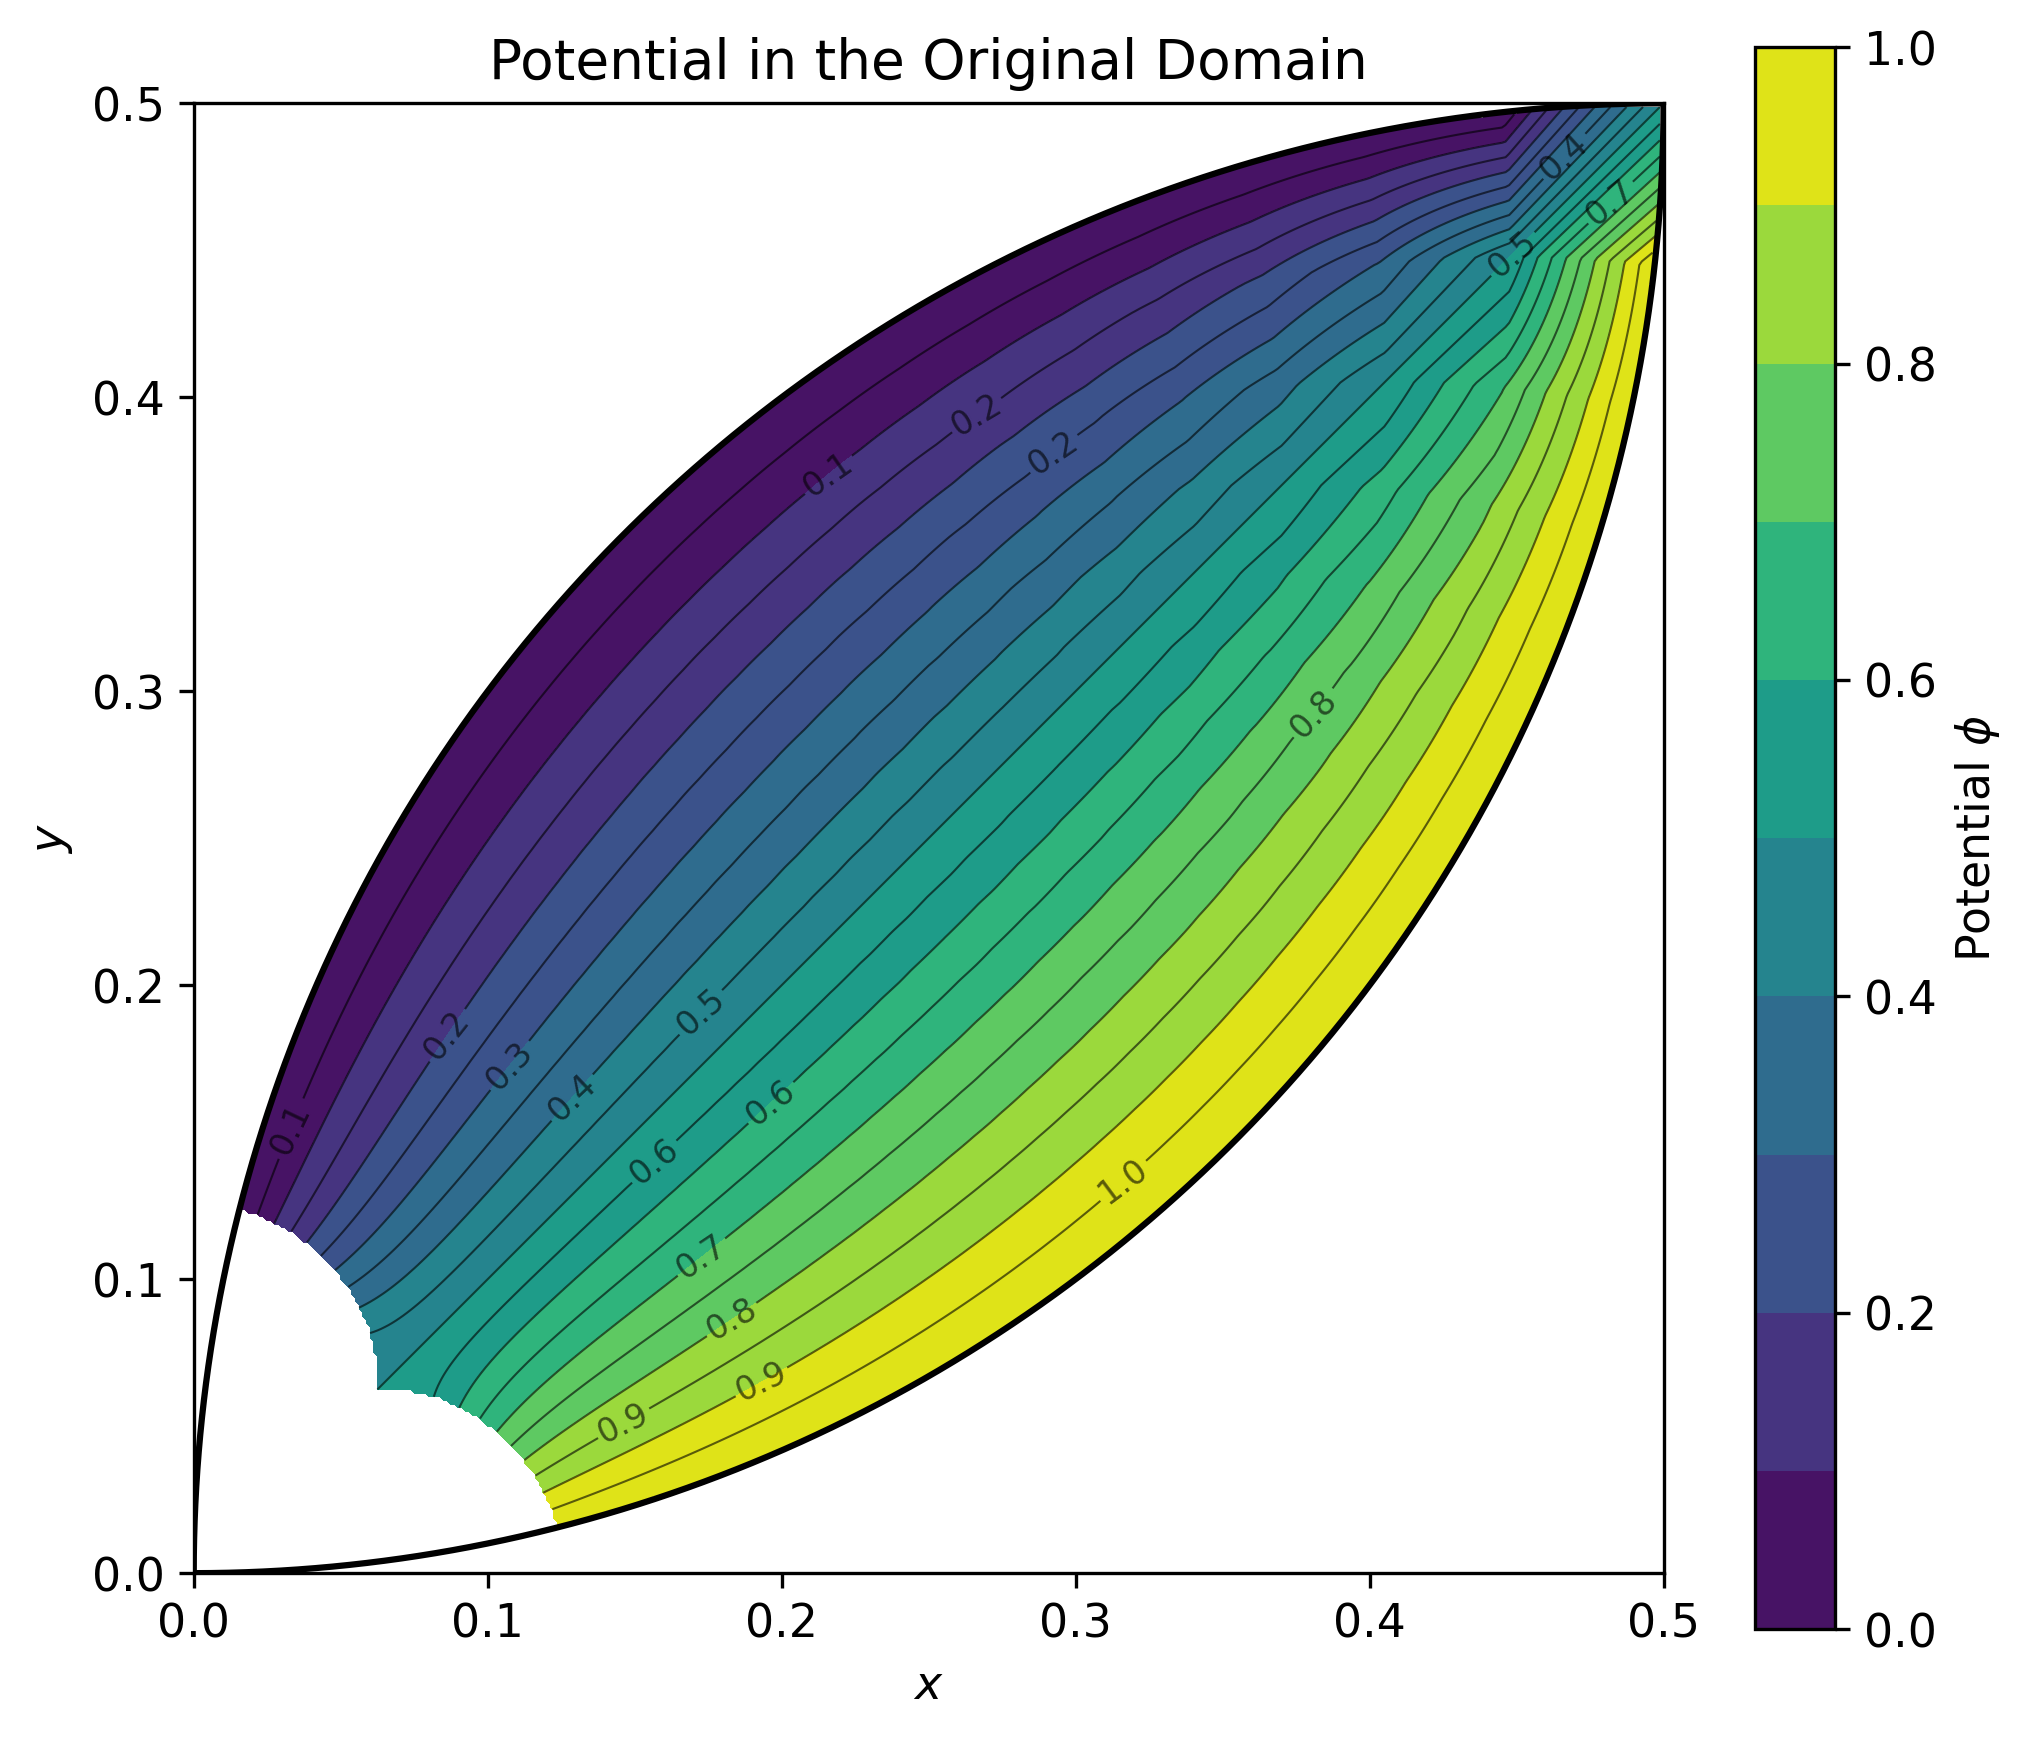

In [17]:
original_potential_figure_path = (
    plot_original_potential(
        original_x_grid=original_x_grid,
        original_y_grid=original_y_grid,
        original_potential=original_potential,
        figures_dir=figures_dir,
    )
)

## Electric Field

The electric field is obtained from the negative gradient of the potential:

$$
\mathbf{E}
=
-\nabla\phi.
$$

The numerical derivatives are first evaluated in the transformed domain, where the solution is defined on a regular Cartesian grid:

$$
\tilde{E}_{x'}
=
-
\frac{\partial\tilde{\phi}}{\partial x'},
\qquad
\tilde{E}_{y'}
=
-
\frac{\partial\tilde{\phi}}{\partial y'}.
$$

The inversion coordinates are

$$
x'
=
\frac{x}{x^2+y^2},
\qquad
y'
=
\frac{y}{x^2+y^2}.
$$

Therefore, the derivatives of the reconstructed potential follow from the chain rule:

$$
\frac{\partial\phi}{\partial x}
=
\frac{\partial\tilde{\phi}}{\partial x'}
\frac{\partial x'}{\partial x}
+
\frac{\partial\tilde{\phi}}{\partial y'}
\frac{\partial y'}{\partial x},
$$

and

$$
\frac{\partial\phi}{\partial y}
=
\frac{\partial\tilde{\phi}}{\partial x'}
\frac{\partial x'}{\partial y}
+
\frac{\partial\tilde{\phi}}{\partial y'}
\frac{\partial y'}{\partial y}.
$$

The derivatives of the inversion map are

$$
\frac{\partial x'}{\partial x}
=
\frac{y^2-x^2}{(x^2+y^2)^2},
\qquad
\frac{\partial x'}{\partial y}
=
-\frac{2xy}{(x^2+y^2)^2},
$$

and

$$
\frac{\partial y'}{\partial x}
=
-\frac{2xy}{(x^2+y^2)^2},
\qquad
\frac{\partial y'}{\partial y}
=
\frac{x^2-y^2}{(x^2+y^2)^2}.
$$

These expressions allow the electric field to be reconstructed without differentiating across the masked boundary of the lens-shaped domain.

In [18]:
def calculate_transformed_electric_field(
    transformed_potential,
    grid_spacing_x,
    grid_spacing_y,
):
    """
    Calculate the electric field in the transformed domain

    Inputs:
    -------
    transformed_potential : numpy.ndarray
        Two-dimensional transformed potential field

    grid_spacing_x : float
        Uniform grid spacing in the horizontal coordinate

    grid_spacing_y : float
        Uniform grid spacing in the vertical coordinate

    Outputs:
    --------
    transformed_electric_field_x : numpy.ndarray
        Horizontal component of the transformed electric field

    transformed_electric_field_y : numpy.ndarray
        Vertical component of the transformed electric field

    transformed_electric_field_magnitude : numpy.ndarray
        Magnitude of the transformed electric field

    Author:
    -------
    Rodrigo Kang

    """
    (
        transformed_potential_gradient_y,
        transformed_potential_gradient_x,
    ) = np.gradient(
        transformed_potential,
        grid_spacing_y,
        grid_spacing_x,
        edge_order=2,
    )

    transformed_electric_field_x = (
        -transformed_potential_gradient_x
    )

    transformed_electric_field_y = (
        -transformed_potential_gradient_y
    )

    transformed_electric_field_magnitude = np.sqrt(
        transformed_electric_field_x**2
        + transformed_electric_field_y**2
    )

    return (
        transformed_electric_field_x,
        transformed_electric_field_y,
        transformed_electric_field_magnitude,
    )

In [19]:
(
    transformed_electric_field_x,
    transformed_electric_field_y,
    transformed_electric_field_magnitude,
) = calculate_transformed_electric_field(
    transformed_potential=transformed_potential,
    grid_spacing_x=grid_spacing_x,
    grid_spacing_y=grid_spacing_y,
)

Interpolators are constructed for the two components of the transformed electric field. These components are then evaluated at the inverted coordinates associated with the original grid.

In [20]:
def create_electric_field_interpolators(
    x_coordinates,
    y_coordinates,
    transformed_electric_field_x,
    transformed_electric_field_y,
):
    """
    Create interpolators for the transformed electric field components

    Inputs:
    -------
    x_coordinates : numpy.ndarray
        One-dimensional horizontal coordinates of the transformed grid

    y_coordinates : numpy.ndarray
        One-dimensional vertical coordinates of the transformed grid

    transformed_electric_field_x : numpy.ndarray
        Horizontal component of the transformed electric field

    transformed_electric_field_y : numpy.ndarray
        Vertical component of the transformed electric field

    Outputs:
    --------
    electric_field_x_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the horizontal transformed field component

    electric_field_y_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the vertical transformed field component

    Author:
    -------
    Rodrigo Kang

    """
    electric_field_x_interpolator = (
        RegularGridInterpolator(
            (
                y_coordinates,
                x_coordinates,
            ),
            transformed_electric_field_x,
            method="linear",
            bounds_error=False,
            fill_value=np.nan,
        )
    )

    electric_field_y_interpolator = (
        RegularGridInterpolator(
            (
                y_coordinates,
                x_coordinates,
            ),
            transformed_electric_field_y,
            method="linear",
            bounds_error=False,
            fill_value=np.nan,
        )
    )

    return (
        electric_field_x_interpolator,
        electric_field_y_interpolator,
    )

In [21]:
(
    electric_field_x_interpolator,
    electric_field_y_interpolator,
) = create_electric_field_interpolators(
    x_coordinates=x_coordinates,
    y_coordinates=y_coordinates,
    transformed_electric_field_x=(
        transformed_electric_field_x
    ),
    transformed_electric_field_y=(
        transformed_electric_field_y
    ),
)

In [22]:
def reconstruct_original_electric_field(
    original_x_grid,
    original_y_grid,
    transformed_x_grid,
    transformed_y_grid,
    valid_original_domain_mask,
    electric_field_x_interpolator,
    electric_field_y_interpolator,
):
    """
    Reconstruct the electric field in the original lens-shaped domain

    Inputs:
    -------
    original_x_grid : numpy.ndarray
        Two-dimensional horizontal coordinate grid in the original domain

    original_y_grid : numpy.ndarray
        Two-dimensional vertical coordinate grid in the original domain

    transformed_x_grid : numpy.ndarray
        Horizontal inverted coordinates associated with the original grid

    transformed_y_grid : numpy.ndarray
        Vertical inverted coordinates associated with the original grid

    valid_original_domain_mask : numpy.ndarray
        Boolean mask identifying valid points in the original domain

    electric_field_x_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the horizontal transformed field component

    electric_field_y_interpolator : scipy.interpolate.RegularGridInterpolator
        Interpolator for the vertical transformed field component

    Outputs:
    --------
    original_electric_field_x : numpy.ndarray
        Horizontal component of the electric field in the original domain

    original_electric_field_y : numpy.ndarray
        Vertical component of the electric field in the original domain

    original_electric_field_magnitude : numpy.ndarray
        Magnitude of the electric field in the original domain

    Author:
    -------
    Rodrigo Kang

    """
    interpolation_points = np.column_stack(
        (
            transformed_y_grid[
                valid_original_domain_mask
            ],
            transformed_x_grid[
                valid_original_domain_mask
            ],
        )
    )

    transformed_field_x_values = (
        electric_field_x_interpolator(
            interpolation_points
        )
    )

    transformed_field_y_values = (
        electric_field_y_interpolator(
            interpolation_points
        )
    )

    original_x_values = original_x_grid[
        valid_original_domain_mask
    ]

    original_y_values = original_y_grid[
        valid_original_domain_mask
    ]

    original_radius_squared = (
        original_x_values**2
        + original_y_values**2
    )

    original_radius_fourth = (
        original_radius_squared**2
    )

    derivative_x_prime_x = (
        original_y_values**2
        - original_x_values**2
    ) / original_radius_fourth

    derivative_x_prime_y = (
        -2.0
        * original_x_values
        * original_y_values
        / original_radius_fourth
    )

    derivative_y_prime_x = (
        derivative_x_prime_y
    )

    derivative_y_prime_y = (
        original_x_values**2
        - original_y_values**2
    ) / original_radius_fourth

    original_field_x_values = (
        transformed_field_x_values
        * derivative_x_prime_x
        + transformed_field_y_values
        * derivative_y_prime_x
    )

    original_field_y_values = (
        transformed_field_x_values
        * derivative_x_prime_y
        + transformed_field_y_values
        * derivative_y_prime_y
    )

    original_electric_field_x = np.full_like(
        original_x_grid,
        np.nan,
        dtype=float,
    )

    original_electric_field_y = np.full_like(
        original_y_grid,
        np.nan,
        dtype=float,
    )

    original_electric_field_x[
        valid_original_domain_mask
    ] = original_field_x_values

    original_electric_field_y[
        valid_original_domain_mask
    ] = original_field_y_values

    original_electric_field_magnitude = np.sqrt(
        original_electric_field_x**2
        + original_electric_field_y**2
    )

    return (
        original_electric_field_x,
        original_electric_field_y,
        original_electric_field_magnitude,
    )

In [23]:
(
    original_electric_field_x,
    original_electric_field_y,
    original_electric_field_magnitude,
) = reconstruct_original_electric_field(
    original_x_grid=original_x_grid,
    original_y_grid=original_y_grid,
    transformed_x_grid=transformed_x_grid,
    transformed_y_grid=transformed_y_grid,
    valid_original_domain_mask=(
        valid_original_domain_mask
    ),
    electric_field_x_interpolator=(
        electric_field_x_interpolator
    ),
    electric_field_y_interpolator=(
        electric_field_y_interpolator
    ),
)

## Electric Field in the Original Domain

The reconstructed electric field is visualised over the original lens-shaped domain. Its magnitude is represented by filled contours, while a subsampled quiver plot indicates the local field direction.

Because inversion amplifies spatial derivatives near the inversion centre, the electric field may become numerically large close to the origin. To prevent these values from dominating the colour scale, the upper plotting limit is defined from a high percentile of the finite field magnitudes. This affects only the visualisation and does not modify the computed field.

The field vectors are normalised before plotting so that the arrows emphasise direction rather than magnitude. The magnitude remains encoded in the background contours.

In [24]:
def plot_original_electric_field(
    original_x_grid,
    original_y_grid,
    original_electric_field_x,
    original_electric_field_y,
    original_electric_field_magnitude,
    figures_dir,
    quiver_step=24,
    magnitude_percentile=99.0,
):
    """
    Plot and save the electric field in the original domain

    Inputs:
    -------
    original_x_grid : numpy.ndarray
        Two-dimensional horizontal coordinate grid in the original domain

    original_y_grid : numpy.ndarray
        Two-dimensional vertical coordinate grid in the original domain

    original_electric_field_x : numpy.ndarray
        Horizontal component of the electric field

    original_electric_field_y : numpy.ndarray
        Vertical component of the electric field

    original_electric_field_magnitude : numpy.ndarray
        Magnitude of the electric field

    figures_dir : pathlib.Path
        Directory used to save the generated figure

    quiver_step : int, optional
        Subsampling interval used for the vector field

    magnitude_percentile : float, optional
        Percentile used as the upper colour-scale limit

    Outputs:
    --------
    figure_path : pathlib.Path
        Path of the saved original-electric-field figure

    Author:
    -------
    Rodrigo Kang

    """
    finite_field_mask = (
        np.isfinite(
            original_electric_field_x
        )
        & np.isfinite(
            original_electric_field_y
        )
        & np.isfinite(
            original_electric_field_magnitude
        )
    )

    finite_magnitudes = (
        original_electric_field_magnitude[
            finite_field_mask
        ]
    )

    if finite_magnitudes.size == 0:
        raise ValueError(
            "The reconstructed electric field "
            "does not contain finite values."
        )

    magnitude_upper_limit = np.percentile(
        finite_magnitudes,
        magnitude_percentile,
    )

    if magnitude_upper_limit <= 0.0:
        magnitude_upper_limit = (
            np.max(
                finite_magnitudes
            )
        )

    if magnitude_upper_limit <= 0.0:
        raise ValueError(
            "The electric-field magnitude "
            "must contain positive values."
        )

    clipped_field_magnitude = np.clip(
        original_electric_field_magnitude,
        0.0,
        magnitude_upper_limit,
    )

    masked_field_magnitude = np.ma.masked_invalid(
        clipped_field_magnitude
    )

    figure, axis = plt.subplots()

    filled_contours = axis.contourf(
        original_x_grid,
        original_y_grid,
        masked_field_magnitude,
        levels=np.linspace(
            0.0,
            magnitude_upper_limit,
            41,
        ),
        cmap="viridis",
        extend="max",
    )

    normalisation_denominator = np.where(
        original_electric_field_magnitude > 0.0,
        original_electric_field_magnitude,
        np.nan,
    )

    normalised_electric_field_x = (
        original_electric_field_x
        / normalisation_denominator
    )

    normalised_electric_field_y = (
        original_electric_field_y
        / normalisation_denominator
    )

    quiver_x_grid = original_x_grid[
        ::quiver_step,
        ::quiver_step,
    ]

    quiver_y_grid = original_y_grid[
        ::quiver_step,
        ::quiver_step,
    ]

    quiver_field_x = (
        normalised_electric_field_x[
            ::quiver_step,
            ::quiver_step,
        ]
    )

    quiver_field_y = (
        normalised_electric_field_y[
            ::quiver_step,
            ::quiver_step,
        ]
    )

    quiver_mask = (
        np.isfinite(
            quiver_field_x
        )
        & np.isfinite(
            quiver_field_y
        )
    )

    axis.quiver(
        quiver_x_grid[
            quiver_mask
        ],
        quiver_y_grid[
            quiver_mask
        ],
        quiver_field_x[
            quiver_mask
        ],
        quiver_field_y[
            quiver_mask
        ],
        color="black",
        pivot="mid",
        angles="xy",
        scale_units="xy",
        scale=28.0,
        width=0.003,
    )

    boundary_parameter = np.linspace(
        0.0,
        np.pi / 2.0,
        400,
    )

    first_sphere_x = (
        0.5
        * np.sin(
            boundary_parameter
        )
    )

    first_sphere_y = (
        0.5
        - 0.5
        * np.cos(
            boundary_parameter
        )
    )

    second_sphere_x = (
        0.5
        - 0.5
        * np.cos(
            boundary_parameter
        )
    )

    second_sphere_y = (
        0.5
        * np.sin(
            boundary_parameter
        )
    )

    axis.plot(
        first_sphere_x,
        first_sphere_y,
        color="black",
        linewidth=1.5,
    )

    axis.plot(
        second_sphere_x,
        second_sphere_y,
        color="black",
        linewidth=1.5,
    )

    colorbar = figure.colorbar(
        filled_contours,
        ax=axis,
    )

    colorbar.set_label(
        r"Electric-field magnitude $|\mathbf{E}|$"
    )

    axis.set_xlabel(
        r"$x$"
    )

    axis.set_ylabel(
        r"$y$"
    )

    axis.set_title(
        "Electric Field in the Original Domain"
    )

    axis.set_xlim(
        0.0,
        0.5,
    )

    axis.set_ylim(
        0.0,
        0.5,
    )

    axis.set_aspect(
        "equal",
        adjustable="box",
    )

    figure.tight_layout()

    figure_path = (
        figures_dir
        / "original-electric-field.png"
    )

    figure.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.close(figure)

    return figure_path

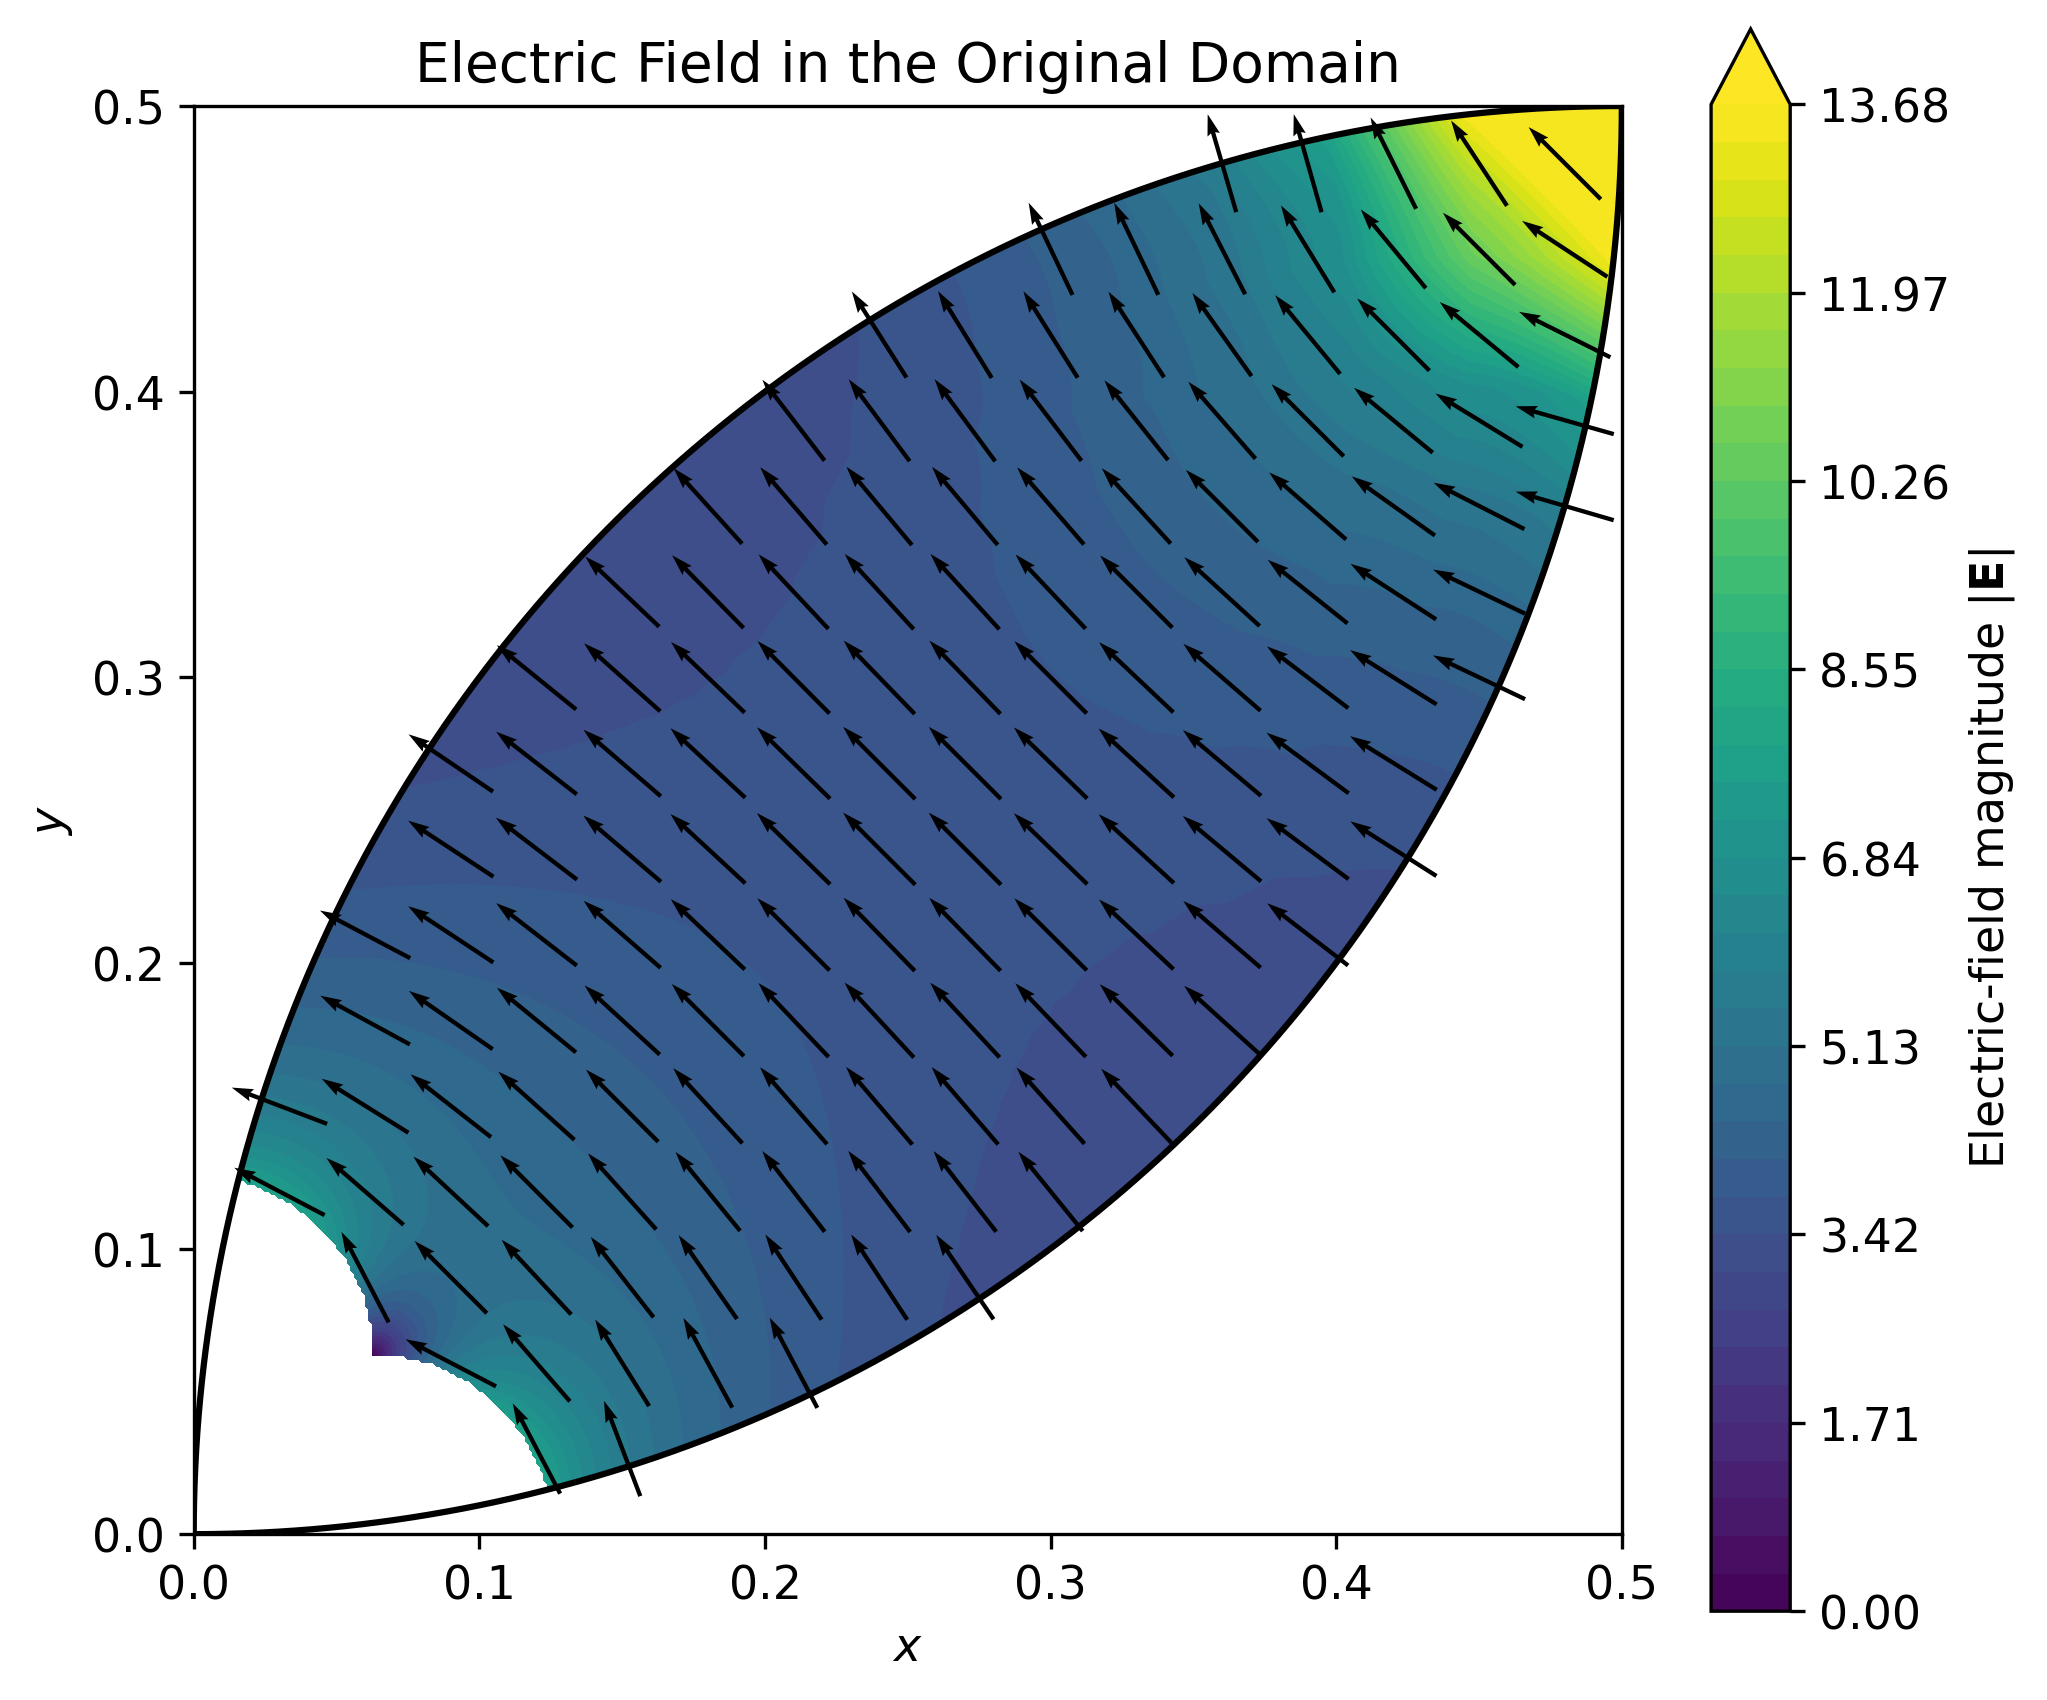

In [25]:
original_electric_field_figure_path = (
    plot_original_electric_field(
        original_x_grid=original_x_grid,
        original_y_grid=original_y_grid,
        original_electric_field_x=(
            original_electric_field_x
        ),
        original_electric_field_y=(
            original_electric_field_y
        ),
        original_electric_field_magnitude=(
            original_electric_field_magnitude
        ),
        figures_dir=figures_dir,
        quiver_step=24,
        magnitude_percentile=99.0,
    )
)

## Numerical Validation

The numerical solution is validated by examining the imposed boundary conditions and the symmetry of the problem.

On the transformed boundaries, the solution should satisfy

$$
\tilde{\phi}(x',1)=1,
$$

and

$$
\tilde{\phi}(1,y')=0.
$$

The artificial outer boundaries satisfy homogeneous Neumann conditions:

$$
\frac{\partial\tilde{\phi}}{\partial x'}(L,y')=0,
$$

and

$$
\frac{\partial\tilde{\phi}}{\partial y'}(x',L)=0.
$$

Because the geometry and outer boundary treatment are symmetric under the exchange $x'\leftrightarrow y'$, while the Dirichlet values are complementary, the solution should also satisfy

$$
\tilde{\phi}(x',y')
+
\tilde{\phi}(y',x')
=
1.
$$

The same complementary symmetry is inherited by the reconstructed solution in the original domain:

$$
\phi(x,y)
+
\phi(y,x)
=
1.
$$

Small deviations from these identities are expected because of grid discretisation, sparse-system solution tolerance, interpolation, and truncation of the unbounded transformed domain.

Errors close to machine precision indicate that the finite difference implementation, interpolation procedure, and inversion mapping are mutually consistent.


In [26]:
def calculate_validation_metrics(
    transformed_potential,
    original_potential,
    grid_spacing_x,
    grid_spacing_y,
):
    """
    Calculate numerical validation metrics for the potential fields

    Inputs:
    -------
    transformed_potential : numpy.ndarray
        Two-dimensional potential field in the transformed domain

    original_potential : numpy.ndarray
        Reconstructed potential field in the original domain

    grid_spacing_x : float
        Uniform horizontal grid spacing in the transformed domain

    grid_spacing_y : float
        Uniform vertical grid spacing in the transformed domain

    Outputs:
    --------
    validation_metrics : dict
        Dictionary containing the numerical validation metrics

    Author:
    -------
    Rodrigo Kang

    """
    bottom_boundary_error = np.max(
        np.abs(
            transformed_potential[
                0,
                1:,
            ]
            - 1.0
        )
    )

    left_boundary_error = np.max(
        np.abs(
            transformed_potential[
                1:,
                0,
            ]
        )
    )

    right_boundary_derivative = (
        transformed_potential[
            :,
            -1,
        ]
        - transformed_potential[
            :,
            -2,
        ]
    ) / grid_spacing_x

    top_boundary_derivative = (
        transformed_potential[
            -1,
            :,
        ]
        - transformed_potential[
            -2,
            :,
        ]
    ) / grid_spacing_y

    right_neumann_error = np.max(
        np.abs(
            right_boundary_derivative[
                1:
            ]
        )
    )

    top_neumann_error = np.max(
        np.abs(
            top_boundary_derivative[
                1:
            ]
        )
    )

    transformed_symmetry_residual = (
        transformed_potential
        + transformed_potential.T
        - 1.0
    )

    transformed_symmetry_error = np.nanmax(
        np.abs(
            transformed_symmetry_residual
        )
    )

    original_transposed_potential = (
        original_potential.T
    )

    original_symmetry_mask = (
        np.isfinite(
            original_potential
        )
        & np.isfinite(
            original_transposed_potential
        )
    )

    original_symmetry_residual = (
        original_potential[
            original_symmetry_mask
        ]
        + original_transposed_potential[
            original_symmetry_mask
        ]
        - 1.0
    )

    if original_symmetry_residual.size > 0:
        original_symmetry_error = np.max(
            np.abs(
                original_symmetry_residual
            )
        )
    else:
        original_symmetry_error = np.nan

    finite_original_potential = original_potential[
        np.isfinite(
            original_potential
        )
    ]

    if finite_original_potential.size == 0:
        original_potential_minimum = np.nan
        original_potential_maximum = np.nan
    else:
        original_potential_minimum = np.min(
            finite_original_potential
        )

        original_potential_maximum = np.max(
            finite_original_potential
        )

    validation_metrics = {
        "bottom_dirichlet_error": (
            bottom_boundary_error
        ),
        "left_dirichlet_error": (
            left_boundary_error
        ),
        "right_neumann_error": (
            right_neumann_error
        ),
        "top_neumann_error": (
            top_neumann_error
        ),
        "transformed_symmetry_error": (
            transformed_symmetry_error
        ),
        "original_symmetry_error": (
            original_symmetry_error
        ),
        "original_potential_minimum": (
            original_potential_minimum
        ),
        "original_potential_maximum": (
            original_potential_maximum
        ),
    }

    return validation_metrics

In [27]:
validation_metrics = calculate_validation_metrics(
    transformed_potential=transformed_potential,
    original_potential=original_potential,
    grid_spacing_x=grid_spacing_x,
    grid_spacing_y=grid_spacing_y,
)

In [28]:
print(
    "Bottom Dirichlet error: "
    f"{validation_metrics['bottom_dirichlet_error']:.6e}"
)

print(
    "Left Dirichlet error: "
    f"{validation_metrics['left_dirichlet_error']:.6e}"
)

print(
    "Right Neumann error: "
    f"{validation_metrics['right_neumann_error']:.6e}"
)

print(
    "Top Neumann error: "
    f"{validation_metrics['top_neumann_error']:.6e}"
)

print(
    "Transformed symmetry error: "
    f"{validation_metrics['transformed_symmetry_error']:.6e}"
)

print(
    "Original symmetry error: "
    f"{validation_metrics['original_symmetry_error']:.6e}"
)

print(
    "Minimum original potential: "
    f"{validation_metrics['original_potential_minimum']:.6f}"
)

print(
    "Maximum original potential: "
    f"{validation_metrics['original_potential_maximum']:.6f}"
)

Bottom Dirichlet error: 0.000000e+00
Left Dirichlet error: 0.000000e+00
Right Neumann error: 0.000000e+00
Top Neumann error: 0.000000e+00
Transformed symmetry error: 1.362244e-13
Original symmetry error: 1.362244e-13
Minimum original potential: 0.000000
Maximum original potential: 1.000000


## Validation Summary

The principal validation metrics are collected in a table to provide a compact summary of the numerical solution. The table includes the boundary-condition residuals, the complementary-symmetry errors, and the range of the reconstructed potential.

The reported values should be interpreted in relation to the discretisation and truncation adopted in the transformed domain. In particular, the Dirichlet residuals are expected to be close to machine precision because those values are imposed directly, whereas the reconstructed-domain metrics also include interpolation effects.

In [29]:
def create_validation_table(
    validation_metrics,
):
    """
    Create a table containing the numerical validation metrics

    Inputs:
    -------
    validation_metrics : dict
        Dictionary containing the numerical validation metrics

    Outputs:
    --------
    validation_table : pandas.DataFrame
        Table containing the validation metrics

    Author:
    -------
    Rodrigo Kang

    """
    validation_table = pd.DataFrame(
        {
            "Metric": [
                "Bottom Dirichlet error",
                "Left Dirichlet error",
                "Right Neumann error",
                "Top Neumann error",
                "Transformed symmetry error",
                "Original symmetry error",
                "Minimum original potential",
                "Maximum original potential",
            ],
            "Value": [
                validation_metrics[
                    "bottom_dirichlet_error"
                ],
                validation_metrics[
                    "left_dirichlet_error"
                ],
                validation_metrics[
                    "right_neumann_error"
                ],
                validation_metrics[
                    "top_neumann_error"
                ],
                validation_metrics[
                    "transformed_symmetry_error"
                ],
                validation_metrics[
                    "original_symmetry_error"
                ],
                validation_metrics[
                    "original_potential_minimum"
                ],
                validation_metrics[
                    "original_potential_maximum"
                ],
            ],
        }
    )

    return validation_table

In [30]:
validation_table = create_validation_table(
    validation_metrics=validation_metrics,
)

validation_table

,Metric,Value
0,Bottom Dirichlet error,0.000000e+00
1,Left Dirichlet error,0.000000e+00
2,Right Neumann error,0.000000e+00
3,Top Neumann error,0.000000e+00
4,Transformed symmetry error,1.362244e-13
5,Original symmetry error,1.362244e-13
6,Minimum original potential,0.000000e+00
7,Maximum original potential,1.000000e+00


In [31]:
def save_validation_table(
    validation_table,
    tables_dir,
):
    """
    Save the numerical validation table

    Inputs:
    -------
    validation_table : pandas.DataFrame
        Table containing the validation metrics

    tables_dir : pathlib.Path
        Directory used to save the generated table

    Outputs:
    --------
    table_path : pathlib.Path
        Path of the saved validation table

    Author:
    -------
    Rodrigo Kang

    """
    table_path = (
        tables_dir
        / "validation-metrics.csv"
    )

    validation_table.to_csv(
        table_path,
        index=False,
    )

    return table_path

In [32]:
validation_table_path = save_validation_table(
    validation_table=validation_table,
    tables_dir=tables_dir,
)

## Numerical Interpretation

The finite difference solution satisfies the prescribed Dirichlet conditions and approximately satisfies the homogeneous Neumann conditions introduced at the truncated outer boundaries.

The complementary symmetry of the transformed solution provides an additional internal consistency check. Because exchanging $x'$ and $y'$ interchanges the two conducting boundaries, the potential should transform into its complement. The small numerical residual confirms that this structure is preserved by the discretisation.

After inversion, the reconstructed potential remains confined approximately to the interval

$$
0
\le
\phi
\le
1.
$$

The electric field is strongest where the equipotential contours are most densely concentrated. Its apparent growth near the inversion centre must be interpreted carefully because this region corresponds to increasingly distant points in the transformed domain and is therefore affected by the finite truncation length.

Overall, the computation demonstrates how inversion converts the curved lens-shaped geometry into a rectangular numerical domain on which the Laplace equation can be solved with a regular finite difference grid. The resulting auxiliary solution can then be interpolated and mapped back to recover the potential and electric field in the original geometry.

## Conclusions


The inversion transforms the intersecting spherical boundaries into a regular Cartesian domain, allowing Laplace's equation to be solved with a standard finite difference discretisation. The transformed solution is then interpolated and mapped back to recover the potential and electric field within the original lens-shaped region.

The numerical checks show that the prescribed boundary conditions, the complementary symmetry of the problem, and the expected potential range are all preserved to numerical precision. The small undefined region near the inversion centre is a controlled consequence of truncating the unbounded transformed domain and can be reduced by increasing the truncation distance.

This example illustrates the practical value of conformal inversion as a geometric preprocessing step: a curved electrostatic configuration is converted into a domain that is straightforward to discretise, solve, validate, and reconstruct numerically.
